In [121]:
#%pip install pulser
#%pip install pulser-core
#%pip install myqlm

In [122]:
from pulser import Pulse, Sequence, Register
from pulser.devices import MockDevice
from pulser.devices import DigitalAnalogDevice
from pulser import waveforms
from pulser_simulation import QutipEmulator
from scipy.spatial.distance import pdist, squareform
import qutip
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import itertools

In [123]:
#Dictionnary of our antennas and their positions

coords = {
    1: (0, 0),
    2: (3, 5.2),
    3: (6, 0),
    4: (9, -5.2),
    5: (9, 0),
    6: (9, 5.2),
    7: (9, 10.4),
    8: (12, 0)
}
radius = 8.7

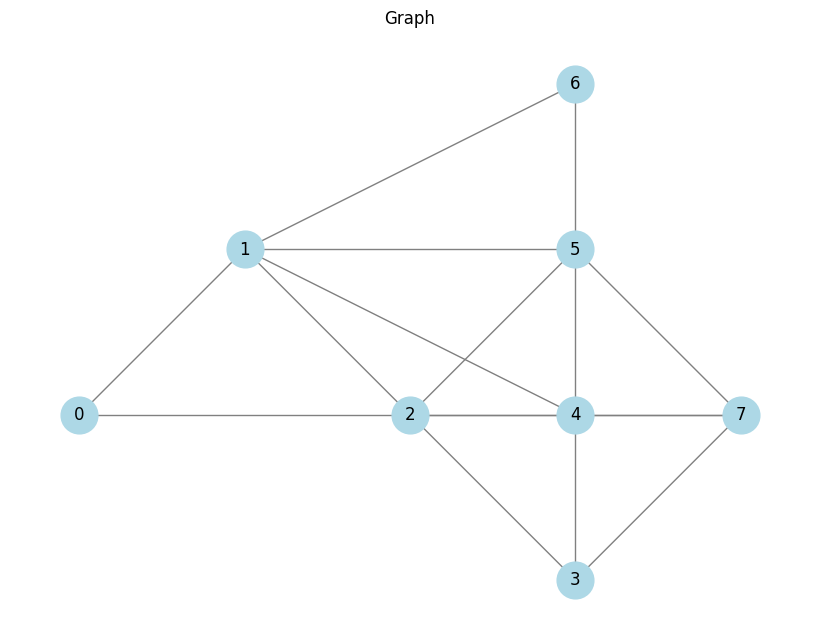

In [124]:
#This function is meant to recreate our antennas problem using a graph
def create_coloring_graph(coords, radius):
    G = nx.Graph()

    #Extraction of the antennas position as described in the coords dictionnary
    positions = list(coords.values())
    for i, coord1 in enumerate(positions):
        for j, coord2 in enumerate(positions[i + 1:], start=i + 1):
            distance = np.linalg.norm(np.array(coord1) - np.array(coord2))
            if distance <= radius:
                G.add_edge(i, j)
    return G

#Graphe creation
coloring_graph = create_coloring_graph(coords, radius)

#Our graph is numbered from 0 to 7 but our antennas are name from 1 to 8.
#We are using this command to solve that and to place our antennas
pos = {node: coords[node + 1] for node in coloring_graph.nodes}

#Visualisation
plt.figure(figsize=(8, 6))
nx.draw(coloring_graph, pos, with_labels=True, node_size=700, node_color="lightblue", edge_color="gray")
plt.title("Graph")
plt.show()

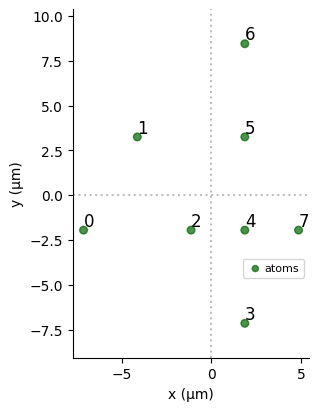

In [125]:
#Creating the pulser register

reg = Register.from_coordinates(coords.values())
reg.draw()

In [126]:
def MIS_solver(reg, T):
  seq = Sequence(reg, MockDevice)
  seq.declare_channel("ch", "rydberg_global")

  amplitude = waveforms.InterpolatedWaveform(T, [0, 10, 0])
  detuning = waveforms.InterpolatedWaveform(T, [-20, 0, 20])
  pulse = Pulse(amplitude, detuning, 0)
  seq.add(pulse, "ch")

  sim = QutipEmulator.from_sequence(seq)
  result = sim.run()
  return result.sample_final_state(1000)

In [127]:
#Testing the MIS solver.
for T in [100, 200, 300, 400, 500]:
    print(MIS_solver(reg, T))

Counter({'00000000': 397, '00100000': 79, '00001000': 73, '00000100': 70, '00010000': 61, '00000001': 57, '01000000': 55, '10000000': 53, '00000010': 52, '00100010': 11, '01000001': 8, '10000010': 8, '10001000': 8, '10010000': 8, '00000011': 7, '00010010': 7, '01000010': 7, '10000001': 7, '00001010': 6, '00010100': 6, '01010000': 6, '10000100': 5, '01001000': 4, '01000011': 1, '01001010': 1, '10000011': 1, '10001010': 1, '10010010': 1})
Counter({'00100000': 97, '00100010': 69, '00001000': 57, '01000001': 56, '00010100': 55, '00000100': 49, '01010000': 48, '10000100': 46, '10000001': 44, '00000001': 42, '00001010': 42, '01001000': 36, '10001000': 35, '01000000': 34, '00010010': 32, '10010100': 31, '00000011': 29, '10000011': 29, '10010000': 25, '10010010': 24, '10001010': 22, '00010000': 19, '10000010': 18, '01010010': 15, '01000010': 14, '01000011': 14, '10000000': 7, '01001010': 5, '00000010': 4, '00000000': 2})
Counter({'01010000': 80, '10000011': 79, '00100010': 76, '10010100': 76, 

In [128]:
#The goal of this fonction is to assign colors to nodes depending of their coordinates. For that we are using the MIS described earlier.

def graph_coloring_solver(graph, coords, colors_freq):

    _, nodes = graph
    node_coords = [coords[node + 1] for node in nodes]
    node_list = list(nodes)

    # Color initialisation
    num_colors = len(colors_freq)
    node_colors = [num_colors] * len(nodes)

    # Assign color to nodes
    current_color = 0
    for threshold in colors_freq:
        # Register creation from the coordinates
        register = Register.from_coordinates(node_coords)

        # MIS application
        solution_counter = MIS_solver(register, threshold)
        most_common_solution, _ = solution_counter.most_common()[0]

        # Color update
        for i in range(len(most_common_solution) - 1, -1, -1):
            if most_common_solution[i] == '1':
                node_colors[node_list[i]] = current_color
                node_coords.pop(i)
                node_list.pop(i)
        current_color += 1

    return node_colors


In [129]:
#Execution of our program
colors_freq = [100,200,300,400,500]
graph_color = graph_coloring_solver((E,V), coords, colors_freq)
print("Success ! Here is our colored graph : ")
print(graph_color)

Success ! Here is our colored graph : 
[2, 4, 1, 2, 3, 2, 3, 4]


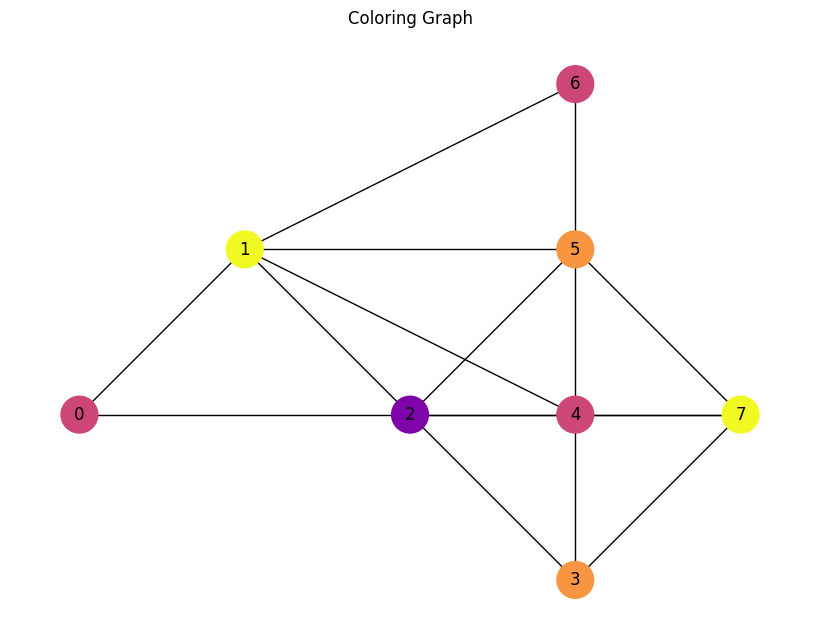

In [130]:
# Get colors
cmap = plt.get_cmap('plasma', max(graph_color) + 1)
node_colors = [cmap(color) for color in graph_color]

# Print Colored Graph
plt.figure(figsize=(8, 6))
nx.draw(coloring_graph, pos, with_labels=True, node_size=700, node_color=node_colors)
plt.title("Coloring Graph")
plt.show()